In [6]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("pnkjgpt/butterfly-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'butterfly-classification-dataset' dataset.
Path to dataset files: /kaggle/input/butterfly-classification-dataset
Contents of base_path (/kaggle/input):
['butterfly-classification-dataset']
Contents of path (/kaggle/input/butterfly-classification-dataset):
['Train']


In [8]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define the path to the main training directory
train_dir = os.path.join(path, 'Train')

# FIX: Use '/content/' instead of 'base_path' (which was /kaggle/input)
# '/content/' is writable in Google Colab
split_base_dir = '/content/split_dataset'

# Create new train and test directories
new_train_dir = os.path.join(split_base_dir, 'train')
new_test_dir = os.path.join(split_base_dir, 'test')

os.makedirs(new_train_dir, exist_ok=True)
os.makedirs(new_test_dir, exist_ok=True)

print(f"Original training data directory: {train_dir}")
print(f"New training data will be stored in: {new_train_dir}")
print(f"New testing data will be stored in: {new_test_dir}")

# List all subdirectories (classes) in the original train_dir
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    images = [os.path.join(class_path, f) for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

    # Split images into train (80%) and test (20%)
    train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

    # Create class specific directories in new train/test folders
    os.makedirs(os.path.join(new_train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(new_test_dir, class_name), exist_ok=True)

    # Copy training images to the new train directory
    for img_path in train_images:
        shutil.copy(img_path, os.path.join(new_train_dir, class_name, os.path.basename(img_path)))

    # Copy testing images to the new test directory
    for img_path in test_images:
        shutil.copy(img_path, os.path.join(new_test_dir, class_name, os.path.basename(img_path)))

    print(f"Processed Class '{class_name}'")

print("Dataset split into training and testing sets successfully in /content/!")

Original training data directory: /kaggle/input/butterfly-classification-dataset/Train
New training data will be stored in: /content/split_dataset/train
New testing data will be stored in: /content/split_dataset/test
Processed Class 'pipevine swallow'
Processed Class 'grey hairstreak'
Processed Class 'malachite'
Processed Class 'cabbage white'
Processed Class 'copper tail'
Processed Class 'orange oakleaf'
Processed Class 'orange tip'
Processed Class 'southern dogface'
Processed Class 'sixspot burnet'
Processed Class 'american snoot'
Processed Class 'crimson patch'
Processed Class 'zebra long wing'
Processed Class 'great eggfly'
Processed Class 'gold banded'
Processed Class 'purple hairstreak'
Processed Class 'question mark'
Processed Class 'julia'
Processed Class 'orchard swallow'
Processed Class 'paper kite'
Processed Class 'sootywing'
Processed Class 'an 88'
Processed Class 'two barred flasher'
Processed Class 'clodius parnassian'
Processed Class 'red admiral'
Processed Class 'mornin

In [9]:
# Verify the structure and counts
print(f"Contents of {new_train_dir}:")
for class_name in os.listdir(new_train_dir):
    print(f"  {class_name}: {len(os.listdir(os.path.join(new_train_dir, class_name)))} images")

print(f"Contents of {new_test_dir}:")
for class_name in os.listdir(new_test_dir):
    print(f"  {class_name}: {len(os.listdir(os.path.join(new_test_dir, class_name)))} images")


Contents of /content/split_dataset/train:
  julia: 83 images
  large marble: 57 images
  orange tip: 64 images
  indra swallow: 83 images
  clouded sulphur: 68 images
  clodius parnassian: 56 images
  ulyses: 52 images
  southern dogface: 68 images
  adonis: 69 images
  orchard swallow: 58 images
  skipper: 98 images
  red spotted purple: 68 images
  peacock: 70 images
  red admiral: 65 images
  yellow swallow tail: 77 images
  an 88: 66 images
  black hairstreak: 64 images
  malachite: 75 images
  paper kite: 66 images
  eastern coma: 69 images
  beckers white: 84 images
  mangrove skipper: 64 images
  zebra long wing: 78 images
  sixspot burnet: 72 images
  silver spot skipper: 68 images
  grey hairstreak: 71 images
  copper tail: 96 images
  crimson patch: 74 images
  metalmark: 78 images
  question mark: 79 images
  chestnut: 64 images
  morning cloak: 64 images
  straited queen: 69 images
  gold banded: 75 images
  scarce swallow: 100 images
  sootywing: 92 images
  banded peacock

In [10]:
import tensorflow as tf

# 1. Check GPU activity
print("TensorFlow version:", tf.__version__)
devices = tf.config.list_physical_devices('GPU')

if len(devices) > 0:
    print(f"GPU is available: {devices[0]}")
    # Enable memory growth to avoid allocating all memory at once
    tf.config.experimental.set_memory_growth(devices[0], True)
else:
    print("GPU is NOT available. Using CPU instead.")

TensorFlow version: 2.20.0
GPU is available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [11]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

# 2. Prepare Data
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Loading datasets using the directories created in previous steps
train_ds = image_dataset_from_directory(
    new_train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = image_dataset_from_directory(
    new_test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Data Augmentation & Preprocessing
# DenseNet expects inputs in the range [-1, 1]
preprocess_input = tf.keras.applications.densenet.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

# 3. Build DenseNet Model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model for transfer learning

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Found 3562 files belonging to 50 classes.
Found 917 files belonging to 50 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 86s 500ms/step - accuracy: 0.2428 - loss: 2.9805 - val_accuracy: 0.7339 - val_loss: 1.4095
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.6188 - loss: 1.3752 - val_accuracy: 0.8408 - val_loss: 0.7333
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 179ms/step - accuracy: 0.7549 - loss: 0.8784 - val_accuracy: 0.8920 - val_loss: 0.4894
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 172ms/step - accuracy: 0.8077 - loss: 0.6686 - val_accuracy: 0.9106 - val_loss: 0.3850
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 178ms/step - accuracy: 0.8363 - loss: 0.5502 - val_accuracy: 0.9117 - val_loss: 0.3406
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - accuracy: 0.8661 - loss: 0.4647 - val_accuracy: 0.9138 - val_loss: 0.3214
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - accuracy: 0.8880 - loss

In [12]:
# 5. Summarize Training Results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy:   0.9149
Final Validation Accuracy: 0.9346
Final Training Loss:       0.3007
Final Validation Loss:     0.2560


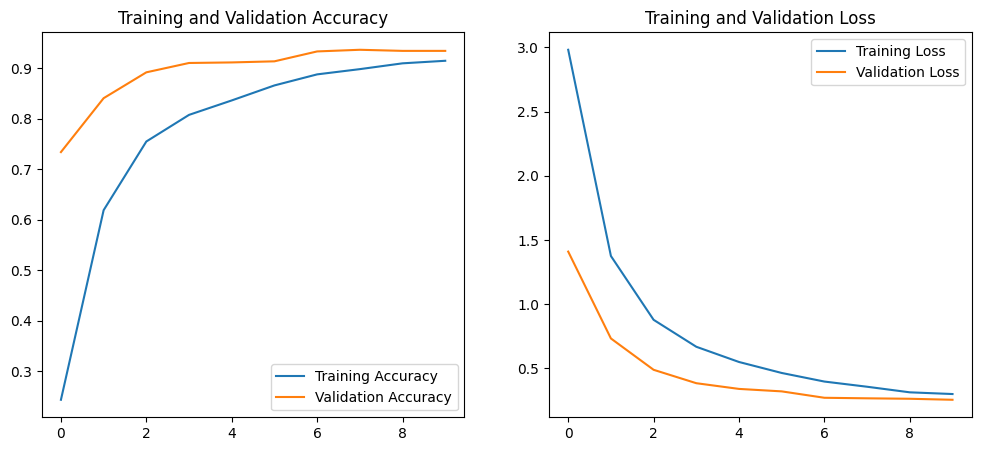

In [13]:
import matplotlib.pyplot as plt

# 6. Display Training Plots
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()